In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/borg_traces_data.csv")
df.head()


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [32]:
print("columns")
print(df.columns)
print("shape")
print(df.shape)
print("info")
print(df.info())

columns
Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='str')
shape
(405894, 34)
info
<class 'pandas.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed

In [33]:
df.isna().sum().sort_values(ascending=False)

cycles_per_instruction             124688
memory_accesses_per_instruction    124688
scheduler                             959
vertical_scaling                      959
resource_request                      774
tail_cpu_usage_distribution             0
cpu_usage_distribution                  0
sample_rate                             0
cluster                                 0
event                                   0
page_cache_memory                       0
assigned_memory                         0
random_sample_usage                     0
maximum_usage                           0
average_usage                           0
end_time                                0
start_time                              0
Unnamed: 0                              0
time                                    0
start_after_collection_ids              0
collection_logical_name                 0
collection_name                         0
user                                    0
collections_events_type           

In [34]:
df['event'].value_counts()

event
FINISH            92867
FAIL              92678
ENABLE            75907
SCHEDULE          69104
LOST              59515
EVICT             14756
KILL                951
UPDATE_PENDING      111
QUEUE                 4
UPDATE_RUNNING        1
Name: count, dtype: int64

In [35]:
df['failed'].value_counts()

failed
0    313216
1     92678
Name: count, dtype: int64

consider FAILURE = event == FAIL OR failed == 1
define the new column to identify all our fail instances

In [36]:
df['label_raw'] = ((df['event'] == 'FAIL') | (df['failed'] == 1)).astype(int)

convert the microsensds to seconds:

In [37]:
df['time_sec'] = df['time'] / 1_000_000

In [38]:
df.head(3)

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1,1,0.000000e+00
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1,1,2.517305e+06
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0,0,1.956840e+05


In [50]:
#sort based on machine id and time to see  the order of events for a specific machine
df = df.sort_values(['machine_id', 'time'])
print(df.columns)
df.head(10)

Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed', 'label_raw', 'time_sec', 'machine_failed',
       'max_time', 'time_to_end', 'label'],
      dtype='str')


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec,machine_failed,max_time,time_to_end,label
121773,121773,409927581858,3,379491243491,1,0,103,0,730,-1,...,[0.00107002 0.00112152 0.00136375 0.00145149 0...,1,FINISH,0,0,4.099276e+05,1,2661315274284,2251387692426,0
8146,8146,518934839788,6,310886846301,0,0,103,0,139,-1,...,[0.07568359 0.07653809 0.07751465 0.07873535 0...,8,SCHEDULE,0,0,5.189348e+05,1,2661315274284,2142380434496,0
271664,271664,644992447229,6,281804868967,1,0,103,0,26,-1,...,[0. 0. 0. 0. 0. 0. 0. 0. 0.],7,SCHEDULE,0,0,6.449924e+05,1,2661315274284,2016322827055,0
245219,245219,675720801728,2,360384371052,2,0,360,330587178063,489,-1,...,[0.0206604 0.02139282 0.02206421 0.02304077 0...,1,FAIL,1,1,6.757208e+05,1,2661315274284,1985594472556,0
37770,37770,753739115177,5,359852128644,2,0,360,330587150465,323,-1,...,[0.0324707 0.03308105 0.03344727 0.03393555 0...,1,LOST,0,0,7.537391e+05,1,2661315274284,1907576159107,0
329314,329314,1000532473578,5,784956094732,2,0,360,698302721875,875,-1,...,[0.00018787 0.00018787 0.00018787 0.00018787 0...,4,LOST,0,0,1.000532e+06,1,2661315274284,1660782800706,0
125234,125234,1063373695920,5,261561502817,2,0,360,261561475113,47,-1,...,[0.06494141 0.06542969 0.06604004 0.06726074 0...,8,LOST,0,0,1.063374e+06,1,2661315274284,1597941578364,0
304903,304903,1251514299099,3,799906496464,0,0,0,0,488,-1,...,[0.01039124 0.01051331 0.01068115 0.01104736 0...,4,FINISH,0,0,1.251514e+06,1,2661315274284,1409800975185,0
271814,271814,1396567039445,2,314637133793,2,0,360,261561487633,348,-1,...,[0.07080078 0.07177734 0.07324219 0.07495117 0...,8,FAIL,1,1,1.396567e+06,1,2661315274284,1264748234839,0
64157,64157,1408120627693,3,285720586621,1,0,103,0,2028,-1,...,[0.00040722 0.00041866 0.00042915 0.0004406 0...,7,FINISH,0,0,1.408121e+06,1,2661315274284,1253194646591,0


check if the machine ever experience failure at some point, then append that to that machine ID
use case machine  168846390496

In [40]:
df['machine_failed'] = df.groupby('machine_id')['label_raw'].transform('max')
df.head(10)


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec,machine_failed
121773,121773,409927581858,3,379491243491,1,0,103,0,730,-1,...,0.018562,1.0,[0.00027561 0.00037098 0.00040054 0.00042343 0...,[0.00107002 0.00112152 0.00136375 0.00145149 0...,1,FINISH,0,0,4.099276e+05,1
8146,8146,518934839788,6,310886846301,0,0,103,0,139,-1,...,0.011268,1.0,[0.01394653 0.03436279 0.04266357 0.05084229 0...,[0.07568359 0.07653809 0.07751465 0.07873535 0...,8,SCHEDULE,0,0,5.189348e+05,1
271664,271664,644992447229,6,281804868967,1,0,103,0,26,-1,...,0.017375,1.0,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],[0. 0. 0. 0. 0. 0. 0. 0. 0.],7,SCHEDULE,0,0,6.449924e+05,1
245219,245219,675720801728,2,360384371052,2,0,360,330587178063,489,-1,...,0.003582,1.0,[0.00024796 0.0059433 0.00828552 0.00942993 0...,[0.0206604 0.02139282 0.02206421 0.02304077 0...,1,FAIL,1,1,6.757208e+05,1
37770,37770,753739115177,5,359852128644,2,0,360,330587150465,323,-1,...,0.003841,1.0,[0.00014782 0.00019836 0.00024796 0.00032806 0...,[0.0324707 0.03308105 0.03344727 0.03393555 0...,1,LOST,0,0,7.537391e+05,1
329314,329314,1000532473578,5,784956094732,2,0,360,698302721875,875,-1,...,0.002585,1.0,[0.00000000e+00 0.00000000e+00 4.76837158e-06 ...,[0.00018787 0.00018787 0.00018787 0.00018787 0...,4,LOST,0,0,1.000532e+06,1
125234,125234,1063373695920,5,261561502817,2,0,360,261561475113,47,-1,...,0.001383,1.0,[8.20159912e-05 1.07765198e-04 1.29699707e-04 ...,[0.06494141 0.06542969 0.06604004 0.06726074 0...,8,LOST,0,0,1.063374e+06,1
304903,304903,1251514299099,3,799906496464,0,0,0,0,488,-1,...,NaN,1.0,[0.00013638 0.00015831 0.00018311 0.00021458 0...,[0.01039124 0.01051331 0.01068115 0.01104736 0...,4,FINISH,0,0,1.251514e+06,1
271814,271814,1396567039445,2,314637133793,2,0,360,261561487633,348,-1,...,0.001694,1.0,[4.10079956e-05 9.24110413e-04 9.64355469e-03 ...,[0.07080078 0.07177734 0.07324219 0.07495117 0...,8,FAIL,1,1,1.396567e+06,1
64157,64157,1408120627693,3,285720586621,1,0,103,0,2028,-1,...,0.016463,1.0,[0.00012684 0.00014591 0.00015926 0.00017357 0...,[0.00040722 0.00041866 0.00042915 0.0004406 0...,7,FINISH,0,0,1.408121e+06,1


assesing time to failure, how far is the system from end of its observed life

In [41]:
df['max_time'] = df.groupby('machine_id')['time'].transform('max')
df['time_to_end'] = df['max_time'] - df['time']
df.head(10)


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec,machine_failed,max_time,time_to_end
121773,121773,409927581858,3,379491243491,1,0,103,0,730,-1,...,[0.00027561 0.00037098 0.00040054 0.00042343 0...,[0.00107002 0.00112152 0.00136375 0.00145149 0...,1,FINISH,0,0,4.099276e+05,1,2661315274284,2251387692426
8146,8146,518934839788,6,310886846301,0,0,103,0,139,-1,...,[0.01394653 0.03436279 0.04266357 0.05084229 0...,[0.07568359 0.07653809 0.07751465 0.07873535 0...,8,SCHEDULE,0,0,5.189348e+05,1,2661315274284,2142380434496
271664,271664,644992447229,6,281804868967,1,0,103,0,26,-1,...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],[0. 0. 0. 0. 0. 0. 0. 0. 0.],7,SCHEDULE,0,0,6.449924e+05,1,2661315274284,2016322827055
245219,245219,675720801728,2,360384371052,2,0,360,330587178063,489,-1,...,[0.00024796 0.0059433 0.00828552 0.00942993 0...,[0.0206604 0.02139282 0.02206421 0.02304077 0...,1,FAIL,1,1,6.757208e+05,1,2661315274284,1985594472556
37770,37770,753739115177,5,359852128644,2,0,360,330587150465,323,-1,...,[0.00014782 0.00019836 0.00024796 0.00032806 0...,[0.0324707 0.03308105 0.03344727 0.03393555 0...,1,LOST,0,0,7.537391e+05,1,2661315274284,1907576159107
329314,329314,1000532473578,5,784956094732,2,0,360,698302721875,875,-1,...,[0.00000000e+00 0.00000000e+00 4.76837158e-06 ...,[0.00018787 0.00018787 0.00018787 0.00018787 0...,4,LOST,0,0,1.000532e+06,1,2661315274284,1660782800706
125234,125234,1063373695920,5,261561502817,2,0,360,261561475113,47,-1,...,[8.20159912e-05 1.07765198e-04 1.29699707e-04 ...,[0.06494141 0.06542969 0.06604004 0.06726074 0...,8,LOST,0,0,1.063374e+06,1,2661315274284,1597941578364
304903,304903,1251514299099,3,799906496464,0,0,0,0,488,-1,...,[0.00013638 0.00015831 0.00018311 0.00021458 0...,[0.01039124 0.01051331 0.01068115 0.01104736 0...,4,FINISH,0,0,1.251514e+06,1,2661315274284,1409800975185
271814,271814,1396567039445,2,314637133793,2,0,360,261561487633,348,-1,...,[4.10079956e-05 9.24110413e-04 9.64355469e-03 ...,[0.07080078 0.07177734 0.07324219 0.07495117 0...,8,FAIL,1,1,1.396567e+06,1,2661315274284,1264748234839
64157,64157,1408120627693,3,285720586621,1,0,103,0,2028,-1,...,[0.00012684 0.00014591 0.00015926 0.00017357 0...,[0.00040722 0.00041866 0.00042915 0.0004406 0...,7,FINISH,0,0,1.408121e+06,1,2661315274284,1253194646591


In [42]:

df['machine_id'].dtype

dtype('int64')

In [43]:
#pick a sample machine id
df[df['machine_id'] == -1]

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec,machine_failed,max_time,time_to_end
121773,121773,409927581858,3,379491243491,1,0,103,0,730,-1,...,[0.00027561 0.00037098 0.00040054 0.00042343 0...,[0.00107002 0.00112152 0.00136375 0.00145149 0...,1,FINISH,0,0,4.099276e+05,1,2661315274284,2251387692426
8146,8146,518934839788,6,310886846301,0,0,103,0,139,-1,...,[0.01394653 0.03436279 0.04266357 0.05084229 0...,[0.07568359 0.07653809 0.07751465 0.07873535 0...,8,SCHEDULE,0,0,5.189348e+05,1,2661315274284,2142380434496
271664,271664,644992447229,6,281804868967,1,0,103,0,26,-1,...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],[0. 0. 0. 0. 0. 0. 0. 0. 0.],7,SCHEDULE,0,0,6.449924e+05,1,2661315274284,2016322827055
245219,245219,675720801728,2,360384371052,2,0,360,330587178063,489,-1,...,[0.00024796 0.0059433 0.00828552 0.00942993 0...,[0.0206604 0.02139282 0.02206421 0.02304077 0...,1,FAIL,1,1,6.757208e+05,1,2661315274284,1985594472556
37770,37770,753739115177,5,359852128644,2,0,360,330587150465,323,-1,...,[0.00014782 0.00019836 0.00024796 0.00032806 0...,[0.0324707 0.03308105 0.03344727 0.03393555 0...,1,LOST,0,0,7.537391e+05,1,2661315274284,1907576159107
329314,329314,1000532473578,5,784956094732,2,0,360,698302721875,875,-1,...,[0.00000000e+00 0.00000000e+00 4.76837158e-06 ...,[0.00018787 0.00018787 0.00018787 0.00018787 0...,4,LOST,0,0,1.000532e+06,1,2661315274284,1660782800706
125234,125234,1063373695920,5,261561502817,2,0,360,261561475113,47,-1,...,[8.20159912e-05 1.07765198e-04 1.29699707e-04 ...,[0.06494141 0.06542969 0.06604004 0.06726074 0...,8,LOST,0,0,1.063374e+06,1,2661315274284,1597941578364
304903,304903,1251514299099,3,799906496464,0,0,0,0,488,-1,...,[0.00013638 0.00015831 0.00018311 0.00021458 0...,[0.01039124 0.01051331 0.01068115 0.01104736 0...,4,FINISH,0,0,1.251514e+06,1,2661315274284,1409800975185
271814,271814,1396567039445,2,314637133793,2,0,360,261561487633,348,-1,...,[4.10079956e-05 9.24110413e-04 9.64355469e-03 ...,[0.07080078 0.07177734 0.07324219 0.07495117 0...,8,FAIL,1,1,1.396567e+06,1,2661315274284,1264748234839
64157,64157,1408120627693,3,285720586621,1,0,103,0,2028,-1,...,[0.00012684 0.00014591 0.00015926 0.00017357 0...,[0.00040722 0.00041866 0.00042915 0.0004406 0...,7,FINISH,0,0,1.408121e+06,1,2661315274284,1253194646591


In [51]:
print(df['machine_id'].value_counts().head(10))

machine_id
 6     20
-1     19
 44    17
 9     14
 49    14
 53    14
 21    12
 24    12
 28    12
 7     11
Name: count, dtype: int64


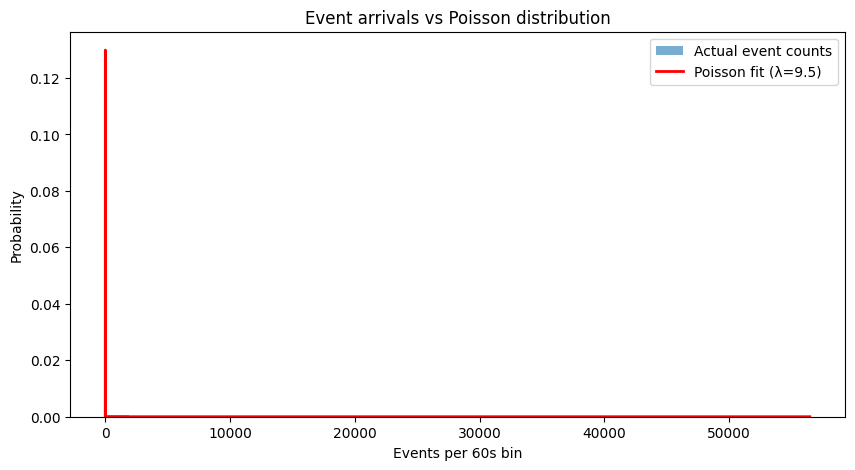

Mean events per interval: 9.52
Variance: 76833.60
If mean ≈ variance → good Poisson fit


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Convert to seconds
df['time_sec'] = df['time'] / 1_000_000

# Bin into intervals (e.g. every 60 seconds) and count events per bin
interval = 60  # seconds
df['time_bin'] = (df['time_sec'] // interval).astype(int)
events_per_bin = df.groupby('time_bin').size()

# Plot actual vs Poisson fit
lambda_ = events_per_bin.mean()  # Poisson parameter = mean count per interval

x = np.arange(0, events_per_bin.max() + 1)
poisson_pmf = stats.poisson.pmf(x, lambda_)

plt.figure(figsize=(10, 5))
plt.hist(events_per_bin, bins=30, density=True, alpha=0.6, label='Actual event counts')
plt.plot(x, poisson_pmf, 'r-', lw=2, label=f'Poisson fit (λ={lambda_:.1f})')
plt.xlabel('Events per 60s bin')
plt.ylabel('Probability')
plt.title('Event arrivals vs Poisson distribution')
plt.legend()
plt.show()

print(f"Mean events per interval: {lambda_:.2f}")
print(f"Variance: {events_per_bin.var():.2f}")
print(f"If mean ≈ variance → good Poisson fit")

#building a prewarning window 30 min,
if the difference between the time for the machine and the maximum time the machine run (time_to_end) is less than the rediction window, and the machine is selected as fail , the label it as 1

In [46]:
HORIZON = 30 * 60


In [ ]:
# df['label'] = ((df['label_raw'] == 1) & (df['time_to_end'] <= HORIZON)).astype(int)
# df.head(5)
# df[df['label'] == 1].head(2)

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,tail_cpu_usage_distribution,cluster,event,failed,label_raw,time_sec,machine_failed,max_time,time_to_end,label
200639,200639,2661315274284,2,281296015739,2,0,360,221495425324,2022,-1,...,[0.00100708 0.00102043 0.00103951 0.00105858 0...,7,FAIL,1,1,2.661315e+06,1,2661315274284,0,1
185716,185716,2578033427919,2,288497456405,3,0,200,288497448483,1066,9,...,[0.00103188 0.00104332 0.00105476 0.00107002 0...,6,FAIL,1,1,2.578033e+06,1,2578033427919,0,1


FEATURES:modelling the system behaviour, we just pick the runtime resource-performance metrics

In [ ]:
# features = df[[
#     'assigned_memory',
#     'page_cache_memory',
#     'cycles_per_instruction',
#     'memory_accesses_per_instruction'
# ]]

what patterns correlate failure rates, does it make sense to track a trainig loss?

In [ ]:
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier

# X = features
# y = df['label']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, shuffle=False
# )

# model = XGBClassifier()
# model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 